In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableSequence
from langchain_core.output_parsers import StrOutputParser

from langgraph.checkpoint.memory import InMemorySaver

import logging
import warnings
from pprint import pprint

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/Users/jayeshp/PycharmProjects/Langgraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Local LLM to generate and optimize post
llm = HuggingFacePipeline.from_model_id(
        model_id="Qwen/Qwen2.5-3B-Instruct",
        task="text-generation",
        pipeline_kwargs={
            "temperature": 0.2,
            "return_full_text":False,
        },
    )

chat_model = ChatHuggingFace(llm=llm)

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 4411.01it/s]


# Short term memory

In [3]:
# state
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
# make joke
def make_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Write a joke on topic : {topic}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input=state["topic"])
    return {"joke": response}

# explain joke
def explain_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Explain the joke : {joke}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input=state["joke"])
    return {"explanation": response}

In [5]:
# checkpointer
checkpointer = InMemorySaver()

# graph
graph = StateGraph(JokeState)

# nodes
graph.add_node("make_joke", make_joke)
graph.add_node("explain_joke", explain_joke)

# edges
graph.add_edge(START, "make_joke")
graph.add_edge("make_joke", "explain_joke")
graph.add_edge("explain_joke", END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)

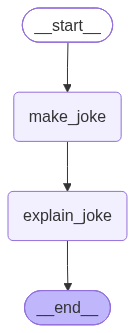

In [6]:
chatbot

In [7]:
# thread config
config_1 = {"configurable": {"thread_id": "1"}}
config_2 = {"configurable": {"thread_id": "2"}}

# invoke for topic : AI
initial_state = {"topic": "AI"}
response = chatbot.invoke(input=initial_state, config=config_1)
print(response)

print("-"*60)

# invoke for topic : China
initial_state = {"topic": "China"}
response = chatbot.invoke(input=initial_state, config=config_2)
print(response)

{'topic': 'AI', 'joke': "Sure! Here's an AI-themed joke for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard there were lots of GPUs (Graphics Processing Units) to train on!", 'explanation': 'That\'s a clever play on words! The joke plays on the idea that "GPU" is also an acronym that stands for "Graphics Processing Unit." By mentioning both the beach and GPUs, it creates a humorous double meaning. The AI character goes to the beach because it hears there are many GPUs available for training purposes. This pun works well within the context of AI technology, as GPUs are commonly used in machine learning and artificial intelligence training processes.'}
------------------------------------------------------------
{'topic': 'China', 'joke': 'Sure, here\'s a light-hearted joke for you:\n\nWhy did the Chinese restaurant refuse to serve the chef?\n\nBecause he ordered too much "chop suey"!', 'explanation': 'This is a play on words and a pun that takes advantage of the homophonic s

In [8]:
# GET FINAL STATE VALUE ONLY
chatbot.get_state(config=config_1)

StateSnapshot(values={'topic': 'AI', 'joke': "Sure! Here's an AI-themed joke for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard there were lots of GPUs (Graphics Processing Units) to train on!", 'explanation': 'That\'s a clever play on words! The joke plays on the idea that "GPU" is also an acronym that stands for "Graphics Processing Unit." By mentioning both the beach and GPUs, it creates a humorous double meaning. The AI character goes to the beach because it hears there are many GPUs available for training purposes. This pun works well within the context of AI technology, as GPUs are commonly used in machine learning and artificial intelligence training processes.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19afba-94d3-6720-8002-9ecaa149d8ef'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-18T11:55:09.307463+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'c

In [10]:
# checkpoint history for topic : AI
pprint(list(chatbot.get_state_history(config=config_1))[-1].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_1))[-2].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_1))[-3].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_1))[-4].values)

{}
----------------------------------------------------------------------------------------------------
{'topic': 'AI'}
----------------------------------------------------------------------------------------------------
{'joke': "Sure! Here's an AI-themed joke for you:\n"
         '\n'
         'Why did the AI go to the beach?\n'
         '\n'
         'Because it heard there were lots of GPUs (Graphics Processing Units) '
         'to train on!',
 'topic': 'AI'}
----------------------------------------------------------------------------------------------------
{'explanation': "That's a clever play on words! The joke plays on the idea "
                'that "GPU" is also an acronym that stands for "Graphics '
                'Processing Unit." By mentioning both the beach and GPUs, it '
                'creates a humorous double meaning. The AI character goes to '
                'the beach because it hears there are many GPUs available for '
                'training purposes. This

In [11]:
# checkpoint history for topic : China
pprint(list(chatbot.get_state_history(config=config_2))[-1].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_2))[-2].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_2))[-3].values)
print("-"*100)
pprint(list(chatbot.get_state_history(config=config_2))[-4].values)

{}
----------------------------------------------------------------------------------------------------
{'topic': 'China'}
----------------------------------------------------------------------------------------------------
{'joke': "Sure, here's a light-hearted joke for you:\n"
         '\n'
         'Why did the Chinese restaurant refuse to serve the chef?\n'
         '\n'
         'Because he ordered too much "chop suey"!',
 'topic': 'China'}
----------------------------------------------------------------------------------------------------
{'explanation': 'This is a play on words and a pun that takes advantage of the '
                'homophonic similarity between "chop suey" (a dish often '
                'served in Chinese restaurants) and "chop suey" (the verb '
                'meaning to cook or prepare food למנ�罩".\n'
                '\n'
                'The joke plays on the idea that the chef might have ordered '
                'an excessive amount of the dish "chop su

# Fault Tolerance

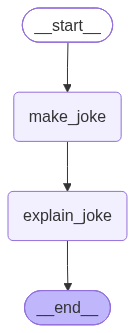

In [3]:
import time

# state
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

# make joke
def make_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Write a joke on topic : {topic}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input=state["topic"])
    print("joke made")
    return {"joke": response}

# explain joke
def explain_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Explain the joke : {joke}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())

    print("Waiting for 30 seconds...")
    time.sleep(30)

    response = chain.invoke(input=state["joke"])
    print("joke explained")
    return {"explanation": response}

# checkpointer
checkpointer = InMemorySaver()

# graph
graph = StateGraph(JokeState)

# nodes
graph.add_node("make_joke", make_joke)
graph.add_node("explain_joke", explain_joke)

# edges
graph.add_edge(START, "make_joke")
graph.add_edge("make_joke", "explain_joke")
graph.add_edge("explain_joke", END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

# state
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

# make joke
def make_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Write a joke on topic : {topic}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input=state["topic"])
    return {"joke": response}

# explain joke
def explain_joke(state: JokeState):
    prompt_template = PromptTemplate.from_template("""
    Explain the joke : {joke}
    """)
    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input=state["joke"])
    return {"explanation": response}

# checkpointer
checkpointer = InMemorySaver()

# graph
graph = StateGraph(JokeState)

# nodes
graph.add_node("make_joke", make_joke)
graph.add_node("explain_joke", explain_joke)

# edges
graph.add_edge(START, "make_joke")
graph.add_edge("make_joke", "explain_joke")
graph.add_edge("explain_joke", END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [4]:
# thread config
config_3 = {"configurable": {"thread_id": "3"}}

# invoke for topic : AI
initial_state = {"topic": "AI"}
response = chatbot.invoke(input=initial_state, config=config_3)
print(response)

joke made
Waiting for 30 seconds...


KeyboardInterrupt: 

In [5]:
# code breaks at explain joke node
list(chatbot.get_state_history(config=config_3))

[StateSnapshot(values={'topic': 'AI', 'joke': "Sure! Here's one for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard there were lots of GPUs (Graphics Processing Units) to train on!"}, next=('explain_joke',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f19afe4-0b62-6c00-8001-2943ff234546'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-18T12:13:42.324727+00:00', parent_config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f19afe3-ec2d-6484-8000-c5d917eca965'}}, tasks=(PregelTask(id='a51f2f48-ea70-7599-6b22-10681a915c4a', name='explain_joke', path=('__pregel_pull', 'explain_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'AI'}, next=('make_joke',), config={'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f19afe3-ec2d-6484-8000-c5d917eca965'}}, metadata={'source': 'loop', 'step': 0, 'parents':

In [6]:
# rerun to show fault tolerance "resume"
response = chatbot.invoke(input=None, config=config_3)
print(response)

Waiting for 30 seconds...
joke explained
{'topic': 'AI', 'joke': "Sure! Here's one for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard there were lots of GPUs (Graphics Processing Units) to train on!", 'explanation': 'This is a clever play on words and a pun that combines elements from both technology and popular culture.\n\nThe joke plays on the term "GPU," which stands for Graphics Processing Unit, a type of specialized computer chip used primarily in video cards for rendering graphics. However, GPUs are also increasingly being used for training artificial intelligence models due to their ability to perform many calculations simultaneously, making them valuable tools in machine learning and deep learning processes.\n\nIn this case, the AI goes to the beach, but instead of going for relaxation or fun, it\'s going because it hears there are lots of GPUs available to train on at the beach. This is a humorous way of suggesting that AI researchers might be looking for places w

In [7]:
list(chatbot.get_state_history(config=config_3))

[StateSnapshot(values={'topic': 'AI', 'joke': "Sure! Here's one for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard there were lots of GPUs (Graphics Processing Units) to train on!", 'explanation': 'This is a clever play on words and a pun that combines elements from both technology and popular culture.\n\nThe joke plays on the term "GPU," which stands for Graphics Processing Unit, a type of specialized computer chip used primarily in video cards for rendering graphics. However, GPUs are also increasingly being used for training artificial intelligence models due to their ability to perform many calculations simultaneously, making them valuable tools in machine learning and deep learning processes.\n\nIn this case, the AI goes to the beach, but instead of going for relaxation or fun, it\'s going because it hears there are lots of GPUs available to train on at the beach. This is a humorous way of suggesting that AI researchers might be looking for places with plenty of GPUs 

# Time travel

In [13]:
# goal to rerun everything from joke generation node
print(list(chatbot.get_state_history(config=config_3))[2].values)
print("-"*60)
print(list(chatbot.get_state_history(config=config_3))[2].config)

{'topic': 'AI'}
------------------------------------------------------------
{'configurable': {'thread_id': '3', 'checkpoint_ns': '', 'checkpoint_id': '1f19afe3-ec2d-6484-8000-c5d917eca965'}}


In [15]:
# joke has changed
chatbot.invoke(input=None, config=list(chatbot.get_state_history(config=config_3))[2].config)

joke made
Waiting for 30 seconds...
joke explained


{'topic': 'AI',
 'joke': "Sure, here's an AI-themed joke for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard it was a great place to train!",
 'explanation': 'That\'s a clever and humorous take on the concept of machine learning models being trained on large datasets! The joke plays on the idea that AI systems are often "trained" on various data sources to improve their performance or learn new skills. By framing this in the context of a beach, which is typically associated with leisure and relaxation, the humor comes from the unexpected juxtaposition between the serious task of training an AI and the casual setting of a beach. It\'s a playful way to highlight the parallels between how humans engage in activities like going to the beach, and how AI systems can instructionally engage with vast amounts of information or data.'}

In [18]:
# new state snapshots added in checkpointer memory
len(list(chatbot.get_state_history(config=config_3)))

7

In [24]:
print(list(chatbot.get_state_history(config=config_3))[0].values)
print("-"*60)
print(list(chatbot.get_state_history(config=config_3))[3].values)

{'topic': 'AI', 'joke': "Sure, here's an AI-themed joke for you:\n\nWhy did the AI go to the beach?\n\nBecause it heard it was a great place to train!", 'explanation': 'That\'s a clever and humorous take on the concept of machine learning models being trained on large datasets! The joke plays on the idea that AI systems are often "trained" on various data sources to improve their performance or learn new skills. By framing this in the context of a beach, which is typically associated with leisure and relaxation, the humor comes from the unexpected juxtaposition between the serious task of training an AI and the casual setting of a beach. It\'s a playful way to highlight the parallels between how humans engage in activities like going to the beach, and how AI systems can instructionally engage with vast amounts of information or data.'}
------------------------------------------------------------
{'topic': 'AI', 'joke': "Sure! Here's one for you:\n\nWhy did the AI go to the beach?\n\nBe